<a href="https://colab.research.google.com/github/MishaE-e/1/blob/main/6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Набор данных: https://archive.ics.uci.edu/dataset/837/product+classification+and+clustering

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import re
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

2. Загрузка данных

In [155]:
df = pd.read_csv('pricerunner_aggregate.csv')

Производитель из Cluster Label

In [156]:
df['Brand'] = df[' Cluster Label'].apply(lambda x: x.split()[0] if pd.notna(x) else 'Unknown')

Распределение производителей до фильтрации

In [157]:
print(df['Brand'].value_counts())

Brand
Bosch               3271
Samsung             2413
Intel               2147
Siemens             1760
Hotpoint            1453
                    ... 
SN436S00GD             1
Maytag                 1
Hotpoint-Ariston       1
Marshall               1
Teknix                 1
Name: count, Length: 284, dtype: int64


Объединяем редкие классы

In [158]:
MIN_SAMPLES_PER_CLASS = 5
brand_counts = df['Brand'].value_counts()
rare_brands_merge = brand_counts[brand_counts < MIN_SAMPLES_PER_CLASS].index.tolist()
df['Brand_clean'] = df['Brand'].apply(lambda x: 'Other' if x in rare_brands_merge else x)

print(df['Brand_clean'].value_counts())

Brand_clean
Bosch       3271
Samsung     2413
Intel       2147
Siemens     1760
Hotpoint    1453
            ... 
Avtex          5
Sage           5
Adelberg       5
Oranier        5
John           5
Name: count, Length: 200, dtype: int64


In [159]:
y = df['Brand_clean']

Создаем текстовые признаки

In [160]:
df['text_features'] = df['Product Title'].fillna('') + ' ' + df[' Category Label'].fillna('')
X_text = df['text_features'].values

Разделение

In [161]:
X_train_text, X_test_text, y_train, y_test = train_test_split (X_text, y, test_size=0.2, random_state=42, stratify=y)

In [162]:
print(f"Размер обучающей выборки: {len(X_train_text)}")
print(f"Размер тестовой выборки: {len(X_test_text)}")
print(f"Распределение классов в train:\n{y_train.value_counts().head(10)}")
print(f"Распределение классов в test:\n{y_test.value_counts().head(10)}")

Размер обучающей выборки: 28248
Размер тестовой выборки: 7063
Распределение классов в train:
Brand_clean
Bosch       2617
Samsung     1930
Intel       1718
Siemens     1408
Hotpoint    1162
Smeg        1098
Sony        1083
Liebherr    1020
LG           955
HP           791
Name: count, dtype: int64
Распределение классов в test:
Brand_clean
Bosch       654
Samsung     483
Intel       429
Siemens     352
Hotpoint    291
Smeg        275
Sony        271
Liebherr    255
LG          239
HP          198
Name: count, dtype: int64


Векторизация

In [163]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print(f"Размер матрицы признаков train: {X_train.shape}")
print(f"Размер матрицы признаков test: {X_test.shape}")

Размер матрицы признаков train: (28248, 5000)
Размер матрицы признаков test: (7063, 5000)


Кодируем целевую переменную

In [164]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(f"Количество классов после кодирования: {len(le.classes_)}")
print(f"Классы: {list(le.classes_)[:10]}...")

Количество классов после кодирования: 200
Классы: ['AEG', 'AMD', 'ASUS', 'Acer', 'Adelberg', 'Akai', 'Alcatel', 'Allcall', 'Allview', 'Amica']...


Обучение модели

In [165]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train_encoded)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [166]:
y_pred = clf.predict(X_test)

In [167]:
print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred):.4f}")
print(f"F1-macro: {f1_score(y_test_encoded, y_pred, average='macro'):.4f}")
print(f"F1-weighted: {f1_score(y_test_encoded, y_pred, average='weighted'):.4f}")

print("Отчет о классификации:")
top_classes = y_train.value_counts().head(15).index
top_indices = [list(le.classes_).index(c) for c in top_classes if c in le.classes_]
target_names_top = [le.classes_[i] for i in top_indices]

print(classification_report(
    y_test_encoded, y_pred,
    labels=top_indices,
    target_names=target_names_top,
    zero_division=0
))

Accuracy: 0.9595
F1-macro: 0.7858
F1-weighted: 0.9574
Отчет о классификации:
              precision    recall  f1-score   support

       Bosch       0.95      0.98      0.96       654
     Samsung       0.98      0.96      0.97       483
       Intel       0.98      1.00      0.99       429
     Siemens       0.98      0.98      0.98       352
    Hotpoint       0.94      0.94      0.94       291
        Smeg       0.98      1.00      0.99       275
        Sony       0.99      1.00      0.99       271
    Liebherr       1.00      1.00      1.00       255
          LG       0.97      0.96      0.96       239
          HP       0.97      0.98      0.97       198
         AEG       0.97      0.95      0.96       179
        Beko       0.98      0.97      0.98       170
        Neff       0.98      0.98      0.98       161
   Panasonic       0.99      0.99      0.99       159
     Zanussi       0.90      0.95      0.92       145

   micro avg       0.97      0.98      0.97      4261
   

Визуализация

In [168]:
brand_stats = df['Brand_clean'].value_counts()
print(f"Всего производителей: {len(brand_stats)}")
print(f"Самый частый: {brand_stats.index[0]} ({brand_stats.iloc[0]} товаров)")
print(f"Самый редкий: {brand_stats.index[-1]} ({brand_stats.iloc[-1]} товаров)")

Всего производителей: 200
Самый частый: Bosch (3271 товаров)
Самый редкий: John (5 товаров)


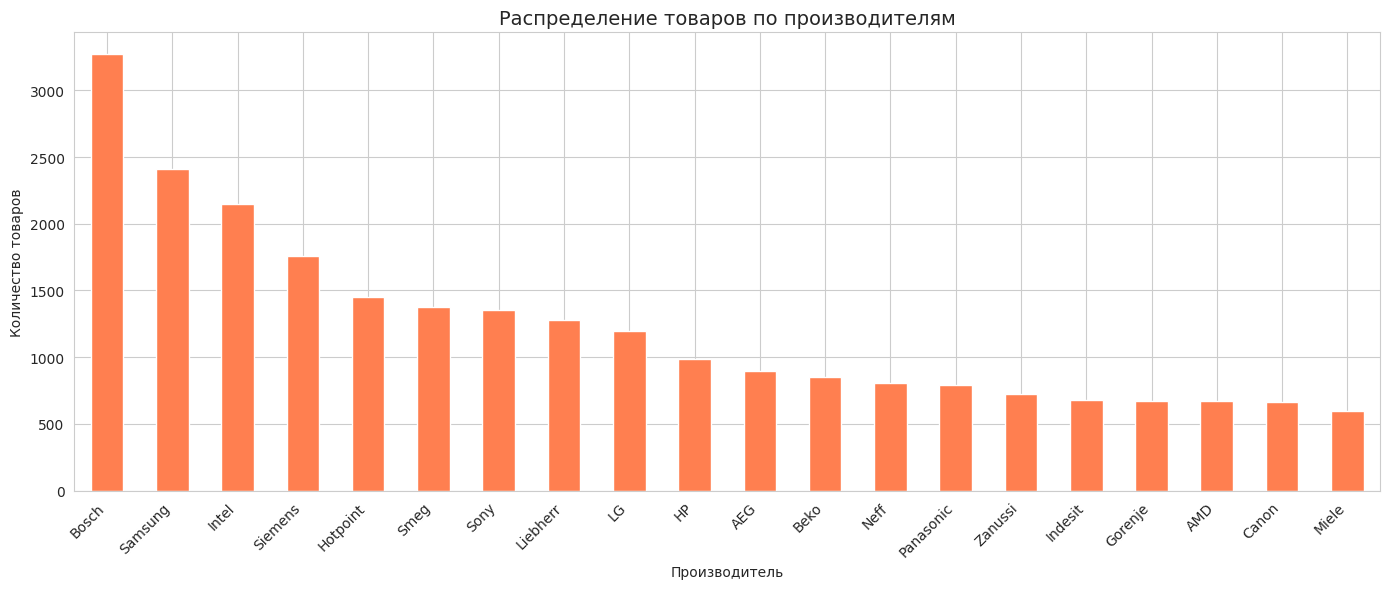

In [169]:
plt.figure(figsize=(14, 6))
brand_stats.head(20).plot(kind='bar', color='coral')
plt.title('Распределение товаров по производителям', fontsize=14)
plt.xlabel('Производитель')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()